# MarketPulse — Statistical Analysis

Descriptive statistics, correlation analysis, and a formal hypothesis test on the processed Delta tables.

**Note on the discount hypothesis test:** Olist has no explicit discount field. We use `payment_type == 'voucher'` as a proxy for discount/coupon usage. Documented here and in NOTES.md.

## 1. Setup — Load Processed Tables

In [0]:
import pandas as pd
import numpy as np
from scipy import stats

customer_features_pd = spark.sql("SELECT * FROM marketpulse_customer_features").toPandas()
transactions_pd = spark.sql(
    "SELECT DISTINCT order_id, customer_id, total_payment_value FROM marketpulse_transactions"
).toPandas()

payments_pd = spark.sql("SELECT * FROM marketpulse_payments").toPandas()

print(f"customer_features_pd: {customer_features_pd.shape}")
print(f"transactions_pd: {transactions_pd.shape}")
print(f"payments_pd: {payments_pd.shape}")

customer_features_pd: (93345, 8)
transactions_pd: (96462, 3)
payments_pd: (103886, 5)


## 2. Descriptive Statistics — Order Value

In [0]:
transactions_pd["total_payment_value"].describe()


count    96461.000000
mean       159.854060
std        218.750373
min          9.590000
25%         61.930000
50%        105.280000
75%        176.330000
max      13664.080000
Name: total_payment_value, dtype: float64

## 3. Visualize Order Value Distribution

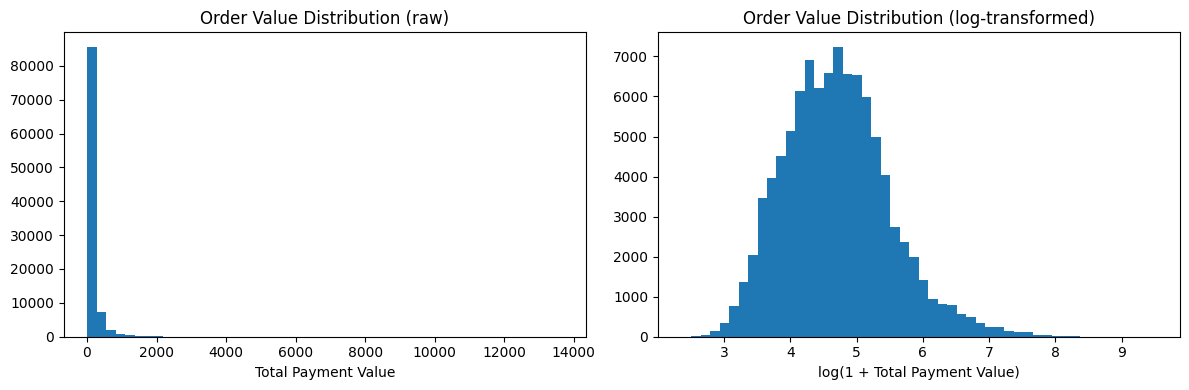

In [0]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(transactions_pd["total_payment_value"], bins=50)
axes[0].set_title("Order Value Distribution (raw)")
axes[0].set_xlabel("Total Payment Value")

axes[1].hist(np.log1p(transactions_pd["total_payment_value"]), bins=50)
axes[1].set_title("Order Value Distribution (log-transformed)")
axes[1].set_xlabel("log(1 + Total Payment Value)")

plt.tight_layout()
plt.show()

## 4. Hypothesis Test — Does Voucher Usage Affect Order Value?

**H0:** Orders paid using a voucher have the same average value as orders paid without a voucher.
**H1:** Orders paid using a voucher have a different average value than orders paid without a voucher.

Two tests run for convergent validation: Mann-Whitney U (robust to the right-skew confirmed above) and a t-test on log-transformed values (valid since the log transform showed approximate normality). Rows with missing `total_payment_value` are dropped before testing, since scipy propagates NaN rather than skipping it (unlike pandas' `.mean()`/`.median()`).

In [0]:
voucher_orders = payments_pd[payments_pd["payment_type"] == "voucher"]["order_id"].unique()
transactions_pd["used_voucher"] = transactions_pd["order_id"].isin(voucher_orders)

voucher_group = transactions_pd[transactions_pd["used_voucher"] == True]["total_payment_value"].dropna()
no_voucher_group = transactions_pd[transactions_pd["used_voucher"] == False]["total_payment_value"].dropna()

print(f"Voucher orders: {len(voucher_group)}")
print(f"Non-voucher orders: {len(no_voucher_group)}")
print(f"Voucher group mean: {voucher_group.mean():.2f}, median: {voucher_group.median():.2f}")
print(f"Non-voucher group mean: {no_voucher_group.mean():.2f}, median: {no_voucher_group.median():.2f}")

u_stat, p_value_mw = stats.mannwhitneyu(voucher_group, no_voucher_group, alternative="two-sided")
print(f"\nMann-Whitney U test: U={u_stat:.2f}, p-value={p_value_mw:.6f}")

log_voucher = np.log1p(voucher_group)
log_no_voucher = np.log1p(no_voucher_group)
t_stat, p_value_t = stats.ttest_ind(log_voucher, log_no_voucher, equal_var=False)
print(f"T-test (log-transformed): t={t_stat:.2f}, p-value={p_value_t:.6f}")

pooled_std = np.sqrt(((len(log_voucher)-1)*log_voucher.std()**2 + (len(log_no_voucher)-1)*log_no_voucher.std()**2)
                      / (len(log_voucher) + len(log_no_voucher) - 2))
cohens_d = (log_voucher.mean() - log_no_voucher.mean()) / pooled_std
print(f"Cohen's d (effect size, log scale): {cohens_d:.4f}")

Voucher orders: 3678
Non-voucher orders: 92783
Voucher group mean: 131.02, median: 87.99
Non-voucher group mean: 161.00, median: 105.96

Mann-Whitney U test: U=148513601.50, p-value=0.000000
T-test (log-transformed): t=-13.73, p-value=0.000000
Cohen's d (effect size, log scale): -0.2229


## 5. Correlation — Delivery Time vs. Repeat Purchase

A correlation here, even if found, does not establish that delivery time *causes* churn — other explanations (e.g., certain categories both ship slower and attract one-time buyers) remain equally plausible.

In [0]:
# Repeat purchase indicator: customer had more than one order
customer_features_pd["is_repeat_customer"] = customer_features_pd["frequency"] > 1

# Only customers with a valid avg_delivery_days (i.e., they had at least one delivered order)
corr_data = customer_features_pd.dropna(subset=["avg_delivery_days"])

# Point-biserial correlation: appropriate here since one variable (repeat purchase) is binary
# and the other (delivery time) is continuous — a standard Pearson correlation would
# technically still run, but point-biserial is the named, correct method for this exact
# binary-vs-continuous pairing, worth using the precise term if asked in an interview
corr, p_value = stats.pointbiserialr(corr_data["is_repeat_customer"], corr_data["avg_delivery_days"])

print(f"Point-biserial correlation: r={corr:.4f}, p-value={p_value:.6f}")
print(f"\nMean delivery time — repeat customers: {corr_data[corr_data['is_repeat_customer']]['avg_delivery_days'].mean():.2f} days")
print(f"Mean delivery time — one-time customers: {corr_data[~corr_data['is_repeat_customer']]['avg_delivery_days'].mean():.2f} days")

Point-biserial correlation: r=-0.0044, p-value=0.175279

Mean delivery time — repeat customers: 12.27 days
Mean delivery time — one-time customers: 12.51 days


## 6. Correlation — Review Score and Repeat Purchase

Review scores are per-order, not per-customer; we use each customer's average review score across their reviewed orders.

**Caveat regardless of result:** repeat customers have more orders and more chances to review, and their reviews accumulate *after* some repeat purchases already happened. A correlation here is consistent with "good reviews → return," but equally consistent with "customers who already returned had more chances to rate." This test alone cannot separate those explanations.

In [0]:
reviews_pd = spark.sql("SELECT * FROM marketpulse_reviews").toPandas()

# Map order_id -> customer_unique_id (reviews only have order_id, not customer identity directly)
order_to_customer = spark.sql("""
    SELECT DISTINCT t.order_id, c.customer_unique_id
    FROM marketpulse_transactions t
    JOIN marketpulse_customers c ON t.customer_id = c.customer_id
""").toPandas()

reviews_with_customer = reviews_pd.merge(order_to_customer, on="order_id", how="inner")

# Average review score per customer (design decision stated above)
avg_review_per_customer = (
    reviews_with_customer.groupby("customer_unique_id")["review_score"]
    .mean()
    .reset_index()
    .rename(columns={"review_score": "avg_review_score"})
)

# Join onto customer_features_pd (which already has is_repeat_customer)
review_corr_data = customer_features_pd.merge(avg_review_per_customer, on="customer_unique_id", how="inner")

print(f"Customers with at least one review: {review_corr_data.shape[0]}")

corr, p_value = stats.pointbiserialr(review_corr_data["is_repeat_customer"], review_corr_data["avg_review_score"])

print(f"\nPoint-biserial correlation: r={corr:.4f}, p-value={p_value:.6f}")
print(f"Mean review score — repeat customers: {review_corr_data[review_corr_data['is_repeat_customer']]['avg_review_score'].mean():.2f}")
print(f"Mean review score — one-time customers: {review_corr_data[~review_corr_data['is_repeat_customer']]['avg_review_score'].mean():.2f}")

Customers with at least one review: 92742

Point-biserial correlation: r=0.0072, p-value=0.027289
Mean review score — repeat customers: 4.21
Mean review score — one-time customers: 4.15


## Summary

Three statistical questions were tested on the processed MarketPulse data:

1. **Voucher usage vs. order value** — Mann-Whitney U and log-transformed t-test both reject H0 (p≈0.000000). Voucher orders are lower in value (mean ₹131.02 vs ₹161.00), but the effect size is small (Cohen's d = -0.2229). Correlational, not causal — voucher use is associated with lower order value, not proven to cause it.

2. **Delivery time vs. repeat purchase** — No significant relationship (r=-0.0044, p=0.175). Genuine null result: delivery time alone does not meaningfully predict repeat-purchase behavior in this dataset.

3. **Review score vs. repeat purchase** — Technically significant (r=0.0072, p=0.027) but practically negligible (0.06-star difference between groups). A clear example of statistical significance without practical significance, made possible by the large sample size (~93,000 customers). Also subject to reverse-causality risk.

**Overall conclusion:** none of the three factors tested show a strong, practically meaningful relationship with repeat-purchase behavior on their own. This suggests repeat purchase in this dataset is driven by factors not captured here, rather than simple satisfaction or pricing proxies — a useful, honest finding for the business recommendations section.